<center><h1>Raza_MohammadHasnain_HW2</h1></center>
<br>
<center><font size="4">Combined Cycle Power Plant Data</font></center>

**Name:** Mohammad Hasnain Raza  
**GitHub Username:** hasnainrazaa03  
**USC ID:** 1259246355

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
# all imports and dependencies
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

# significance level and the seed used for the train/test split
ALPHA = 0.05
SEED = 42

Get the Cycle Power Plant Data Set

In [2]:
# relative path (sheet 1; the other four sheets are shuffled copies of the same data)
DATA_PATH = "../data/CCPP/Folds5x2_pp.xlsx"

# load data, then the predictor columns and the response column
df = pd.read_excel(DATA_PATH, sheet_name="Sheet1")
FEATURES = ["AT", "V", "AP", "RH"]
TARGET = "PE"
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
# size of the data and a check for missing values
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("Missing values per column:", df.isna().sum().to_dict())
df.dtypes

Rows: 9568, Columns: 5
Missing values per column: {'AT': 0, 'V': 0, 'AP': 0, 'RH': 0, 'PE': 0}


AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

**Answer.** The dataset (Sheet1) has **9568 rows and 5 columns**, with no missing values.

- **Rows:** each row is one hourly observation of the power plant running at full load, collected over 2006-2011. Every value is an hourly average.
- **Columns:** four ambient predictors and one response:
  - **AT**: ambient temperature (deg C)
  - **V**: exhaust vacuum (cm Hg)
  - **AP**: ambient pressure (millibar)
  - **RH**: relative humidity (%)
  - **PE**: net hourly electrical energy output (MW), which is the **response**

#### ii. pairwise scatterplots of all the varianbles

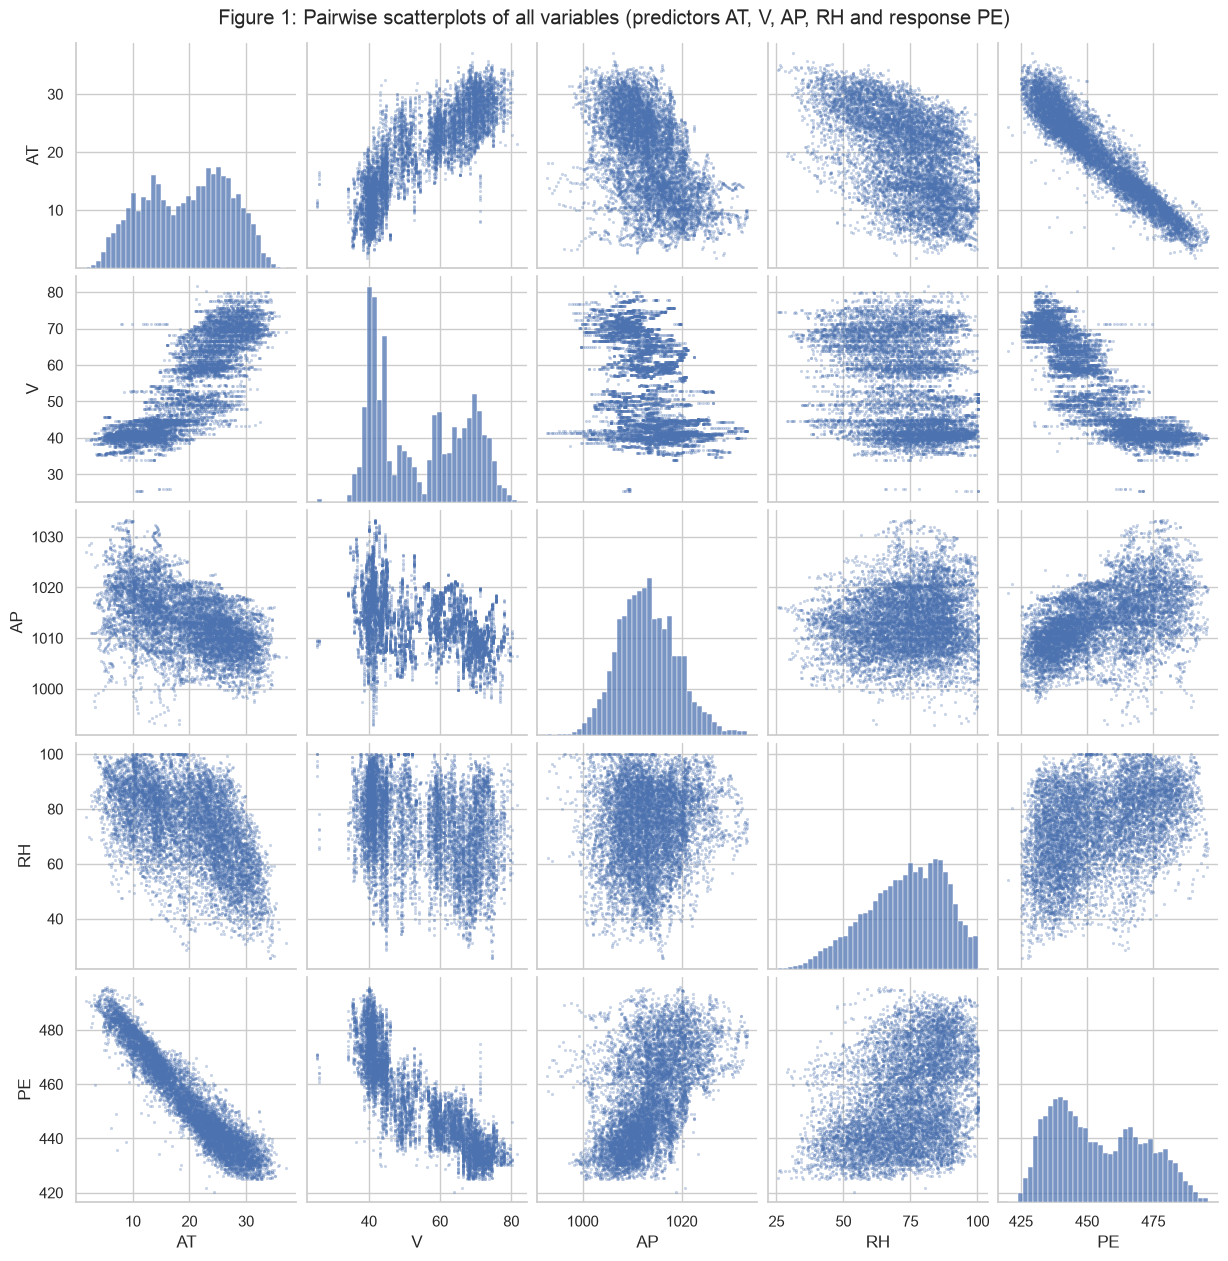

,AT,V,AP,RH,PE
AT,1.0000,0.8441,-0.5075,-0.5425,-0.9481
V,0.8441,1.0000,-0.4135,-0.3122,-0.8698
AP,-0.5075,-0.4135,1.0000,0.0996,0.5184
RH,-0.5425,-0.3122,0.0996,1.0000,0.3898
PE,-0.9481,-0.8698,0.5184,0.3898,1.0000


In [4]:
# scatterplots of every variable pair, including the response
sns.pairplot(df, plot_kws={"s": 4, "alpha": 0.3, "edgecolor": None}, diag_kws={"bins": 40})
plt.suptitle("Figure 1: Pairwise scatterplots of all variables (predictors AT, V, AP, RH and response PE)", y=1.01)
plt.show()

# correlation of every pair
df.corr()

**Answer.** From Figure 1:
- **AT vs PE:** a very strong, almost linear **negative** relationship (r = -0.948). Hotter air is less dense, so the gas turbine produces less power. There is slight curvature at the extremes.
- **V vs PE:** a strong **negative** relationship (r = -0.870). The points fall into vertical bands at particular vacuum levels (V takes clustered, repeated values), so the relationship is not smooth, and the spread within each band is wide.
- **AP vs PE:** a moderate **positive** relationship (r = 0.518) with a lot of scatter.
- **RH vs PE:** a weak **positive** relationship (r = 0.390) with a very diffuse cloud.
- **Among the predictors:** AT and V are strongly positively correlated (r = 0.844), which means **collinearity**. AT is moderately negatively correlated with AP (-0.51) and RH (-0.54). AP and RH are almost uncorrelated (0.10).
- **Distributions:** AT, V and PE are bimodal, which probably reflects seasons (cool vs. hot operating regimes). AP looks roughly normal. RH is left-skewed and piles up near 100%.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
# mean, median, range, quartiles and IQR of every variable
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Min": df.min(),
    "Max": df.max(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25),
})
summary

,Mean,Median,Min,Max,Range,Q1,Q3,IQR
AT,19.6512,20.345,1.81,37.11,35.30,13.5100,25.72,12.2100
V,54.3058,52.080,25.36,81.56,56.20,41.7400,66.54,24.8000
AP,1013.2591,1012.940,992.89,1033.30,40.41,1009.1000,1017.26,8.1600
RH,73.3090,74.975,25.56,100.16,74.60,63.3275,84.83,21.5025
PE,454.3650,451.550,420.26,495.76,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [6]:
# fit PE ~ X separately for each predictor
simple_models = {feature: smf.ols(f"{TARGET} ~ {feature}", data=df).fit() for feature in FEATURES}

# slope, standard error, t, p-value and R^2 of each fit
simple_table = pd.DataFrame({
    feature: {
        "Intercept": model.params["Intercept"],
        "Slope": model.params[feature],
        "Std. error": model.bse[feature],
        "t": model.tvalues[feature],
        "p-value": model.pvalues[feature],
        "R^2": model.rsquared,
        "Residual SE": np.sqrt(model.mse_resid),
    }
    for feature, model in simple_models.items()
}).T
simple_table

,Intercept,Slope,Std. error,t,p-value,R^2,Residual SE
AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989,5.4257
V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565,8.4220
AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688,14.5951
RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519,15.7179


In [7]:
# coefficient table of each simple fit
for feature, model in simple_models.items():
    print(model.summary().tables[1], "\n")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.000     496.727     497.341
AT            -2.1713      0.007   -291.715      0.000      -2.186      -2.157

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    517.8015      0.378   1370.218      0.000     517.061     518.542
V             -1.1681      0.007   -172.402      0.000      -1.181      -1.155

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1055.2610     25.459    -41.449      0.000   -1105.167   -1005.355
AP             1.4899      0.025     59.296      0.000       1.441       1.539

                 coef    std err          t      

**Figure 2** shows the fitted lines on top of the data (top row) and the residuals vs. fitted values (bottom row).

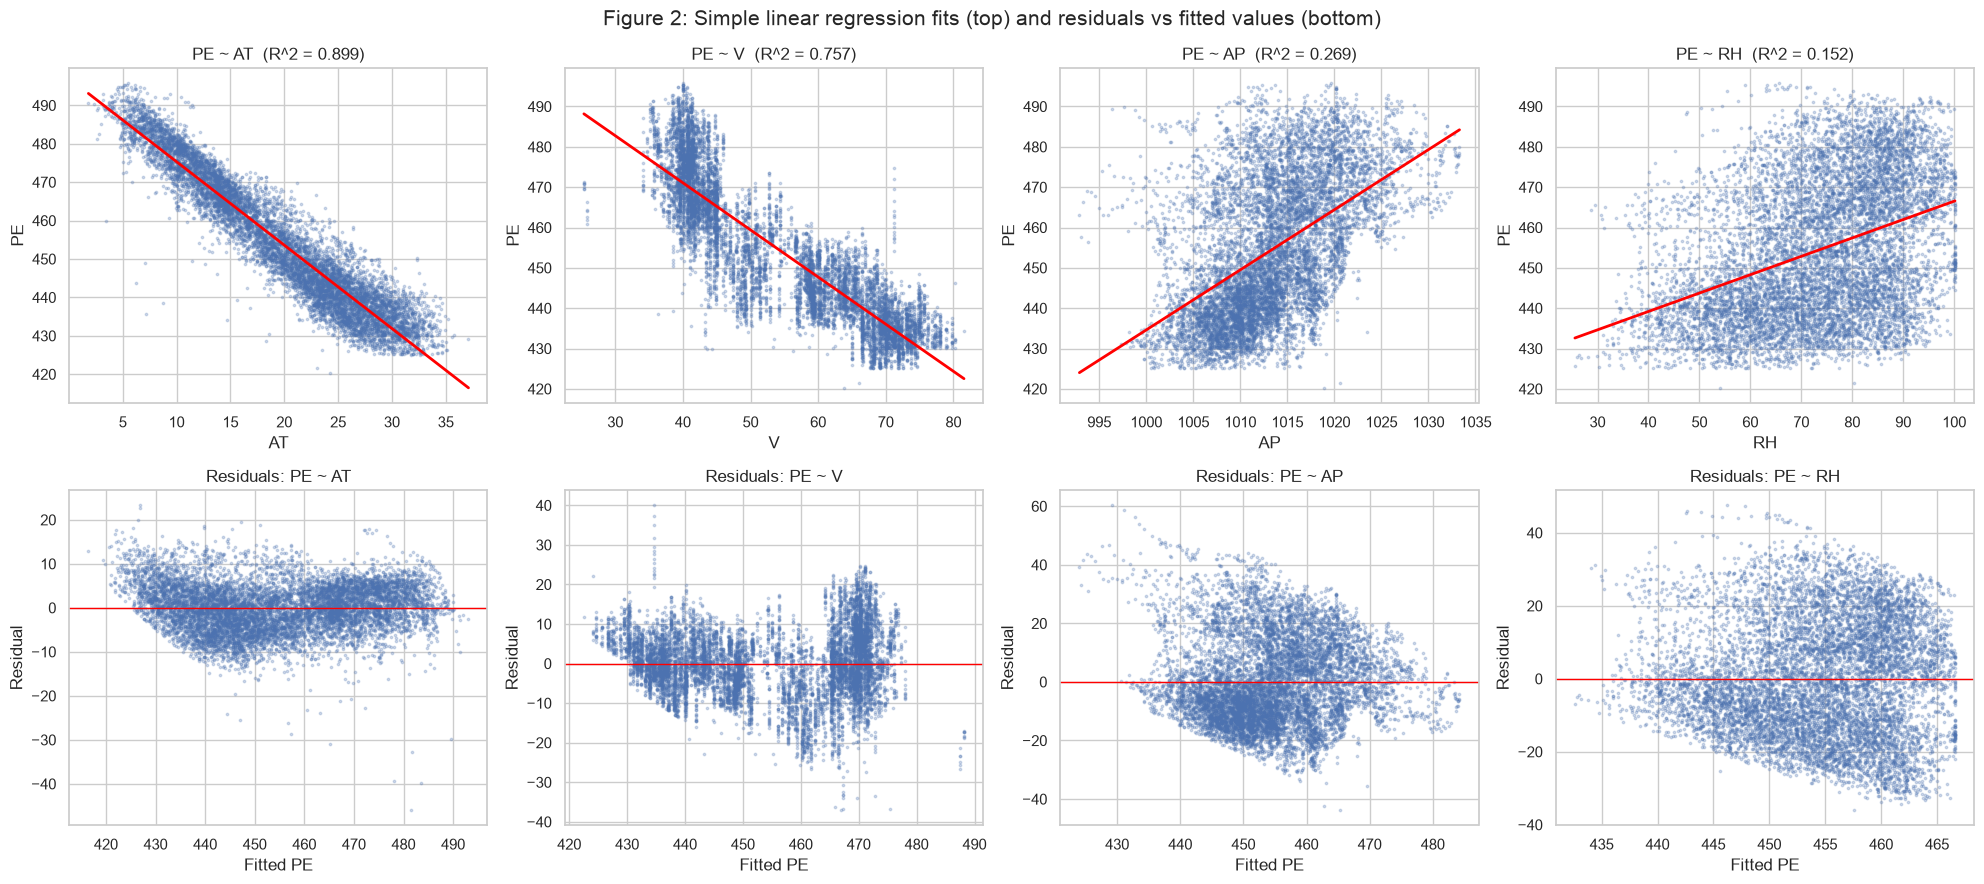

In [8]:
# fitted line over the data (top row) and residuals vs fitted values (bottom row)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for j, (feature, model) in enumerate(simple_models.items()):
    ax = axes[0, j]
    ax.scatter(df[feature], df[TARGET], s=3, alpha=0.25)
    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    ax.plot(x_line, model.params["Intercept"] + model.params[feature] * x_line, color="red", lw=2)
    ax.set(xlabel=feature, ylabel=TARGET, title=f"PE ~ {feature}  (R^2 = {model.rsquared:.3f})")

    ax = axes[1, j]
    ax.scatter(model.fittedvalues, model.resid, s=3, alpha=0.25)
    ax.axhline(0, color="red", lw=1)
    ax.set(xlabel="Fitted PE", ylabel="Residual", title=f"Residuals: PE ~ {feature}")
fig.suptitle("Figure 2: Simple linear regression fits (top) and residuals vs fitted values (bottom)", fontsize=15)
plt.tight_layout()
plt.show()

**Outlier / influence diagnostics.** A point counts as an outlier if its externally studentized residual has $|r_i| > 3$. It counts as a high-leverage point if $h_{ii} > 2(p+1)/n$. It counts as influential if Cook's distance $D_i > 4/n$.

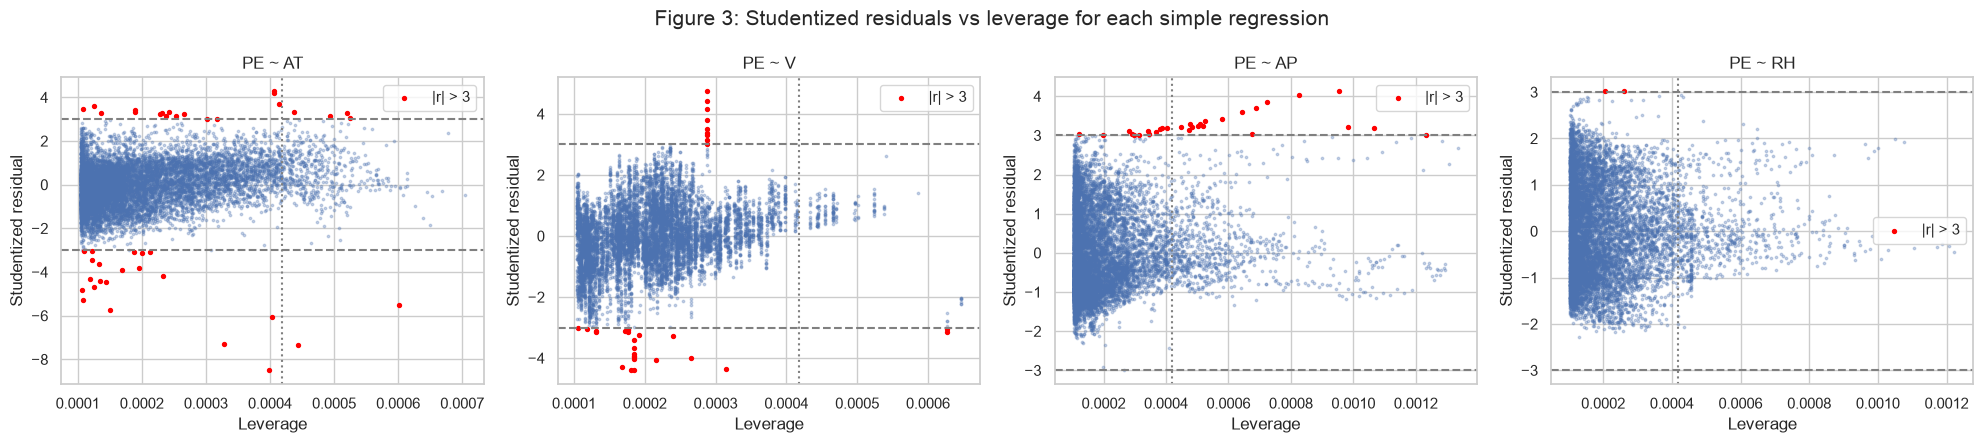

,|stud. resid| > 3,High leverage (h > 4/n),Cook's D > 4/n,Max Cook's D
Predictor,,,,
AT,42,480,416,0.0143
V,33,155,423,0.0032
AP,30,784,300,0.0082
RH,2,707,249,0.0021


In [9]:
# outlier and influence diagnostics for each simple fit
n_rows = len(df)
outlier_rows, outlier_idx = [], {}

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (feature, model) in zip(axes, simple_models.items()):
    influence = model.get_influence()
    stud_resid = influence.resid_studentized_external
    leverage = influence.hat_matrix_diag
    cooks_d = influence.cooks_distance[0]

    # a point is an outlier when its studentized residual is beyond 3
    is_outlier = np.abs(stud_resid) > 3
    outlier_idx[feature] = df.index[is_outlier]
    outlier_rows.append({
        "Predictor": feature,
        "|stud. resid| > 3": int(is_outlier.sum()),
        "High leverage (h > 4/n)": int((leverage > 4 / n_rows).sum()),
        "Cook's D > 4/n": int((cooks_d > 4 / n_rows).sum()),
        "Max Cook's D": cooks_d.max(),
    })

    # studentized residual against leverage, outliers in red
    ax.scatter(leverage, stud_resid, s=3, alpha=0.3)
    ax.scatter(leverage[is_outlier], stud_resid[is_outlier], s=8, color="red", label="|r| > 3")
    ax.axhline(3, ls="--", color="gray")
    ax.axhline(-3, ls="--", color="gray")
    ax.axvline(4 / n_rows, ls=":", color="gray")
    ax.set(xlabel="Leverage", ylabel="Studentized residual", title=f"PE ~ {feature}")
    ax.legend()
fig.suptitle("Figure 3: Studentized residuals vs leverage for each simple regression", fontsize=15)
plt.tight_layout()
plt.show()

pd.DataFrame(outlier_rows).set_index("Predictor")

Refitting each simple model without its $|r_i|>3$ outliers shows how much they actually matter.

In [10]:
# refit each model without its outliers to see how much they change it
refit_rows = []
for feature, model in simple_models.items():
    model_clean = smf.ols(f"{TARGET} ~ {feature}", data=df.drop(index=outlier_idx[feature])).fit()
    refit_rows.append({
        "Predictor": feature,
        "Removed": len(outlier_idx[feature]),
        "Slope (all)": model.params[feature],
        "Slope (cleaned)": model_clean.params[feature],
        "R^2 (all)": model.rsquared,
        "R^2 (cleaned)": model_clean.rsquared,
    })
pd.DataFrame(refit_rows).set_index("Predictor")

,Removed,Slope (all),Slope (cleaned),R^2 (all),R^2 (cleaned)
Predictor,,,,,
AT,42,-2.1713,-2.1802,0.8989,0.9064
V,33,-1.1681,-1.1769,0.7565,0.7670
AP,30,1.4899,1.5401,0.2688,0.2864
RH,2,0.4557,0.4564,0.1519,0.1526


**Answer.**

| Model | Slope | R^2 | Interpretation |
|---|---|---|---|
| PE ~ AT | -2.171 | 0.899 | each +1 degree C lowers output by about 2.17 MW |
| PE ~ V  | -1.168 | 0.757 | each +1 cm Hg of vacuum lowers output by about 1.17 MW |
| PE ~ AP | +1.490 | 0.269 | each +1 mbar raises output by about 1.49 MW |
| PE ~ RH | +0.456 | 0.152 | each +1 % humidity raises output by about 0.46 MW |

**Significance:** **all four** simple regressions show a statistically significant association with PE. Every slope has a p-value near 0 (|t| from 41 to 292), because n = 9568 makes even modest effects easy to detect. Statistical significance is not the same as predictive power, though. AT alone explains about 90% of the variance in PE and V about 76%, while AP (27%) and RH (15%) explain little on their own.

**What the plots show (Figures 2 and 3):** the fitted lines follow the trend for AT and V. The residual plots, however, show clear **structure**, which suggests that a straight line is not the whole story. PE ~ AT has a slight U-shaped curvature. PE ~ V shows band-like clusters. PE ~ AP and PE ~ RH have large, fan-shaped residuals, because most of the variation in PE comes from the predictors left out of those models. These patterns point ahead to (d) and (f).

**Outliers:** the number of points with an externally studentized residual of |r| > 3 is 42 (AT), 33 (V), 30 (AP) and 2 (RH). Many points exceed Cook's D > 4/n, but the **largest Cook's distance is only 0.014**, far below the usual concern level of about 1. So no single point has much influence on any fit. Refitting without the |r| > 3 points barely changes the slopes (for example, AT goes from -2.171 to -2.180 and AP from 1.490 to 1.540). R^2 rises by at most about 0.02, which is expected when you remove the points the model fits worst.

**Conclusion:** these are plausible real operating hours (for example, partial trips or unusual ambient conditions), not data-entry errors, and they have almost no effect on the fits. **I would not remove them.** Removing them would only make the in-sample fit look better than it really is.

### (d) Multiple Regression

In [11]:
# multiple regression on all four predictors
full_model = smf.ols(f"{TARGET} ~ " + " + ".join(FEATURES), data=df).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:08:58   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

In [12]:
# coefficients and whether H0: beta_j = 0 is rejected
pd.DataFrame({
    "Coefficient": full_model.params,
    "p-value": full_model.pvalues,
    f"Reject H0 at alpha={ALPHA}": full_model.pvalues < ALPHA,
}).drop(index="Intercept")

,Coefficient,p-value,Reject H0 at alpha=0.05
AT,-1.9775,0.0000e+00,True
V,-0.2339,4.3753e-215,True
AP,0.0621,5.5071e-11,True
RH,-0.1581,3.1046e-293,True


**Answer.** The multiple regression is

$$\widehat{PE} = 454.61 - 1.978\,AT - 0.234\,V + 0.062\,AP - 0.158\,RH$$

It has **R^2 = 0.929** (adjusted R^2 = 0.929) and a residual standard error of about 4.56 MW. The overall F-statistic is 31,140 with a p-value near 0, so the predictors are clearly jointly useful. Adding the other three predictors raises R^2 from 0.899 (AT alone) to 0.929.

**We can reject $H_0:\beta_j = 0$ for all four predictors (AT, V, AP and RH)** at any conventional level. All p-values are below 1e-10, and AP has the weakest t-statistic at 6.56. AT remains by far the dominant predictor (t = -129).

The large condition number (2.1e5) comes mostly from the scale of AP (about 1013) relative to the intercept. It is not a sign of a problem with the model.

### (e) 1c Compare to 1d

,Simple (1c),Multiple (1d),Change
AT,-2.1713,-1.9775,0.1938
V,-1.1681,-0.2339,0.9342
AP,1.4899,0.0621,-1.4278
RH,0.4557,-0.1581,-0.6137


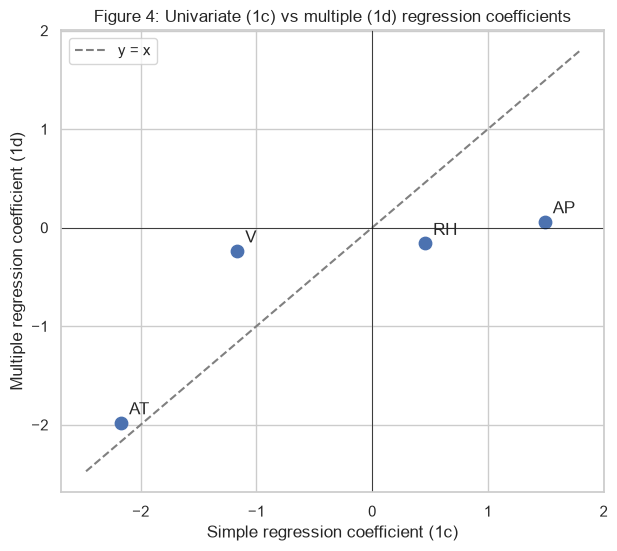

In [13]:
# simple slope against multiple regression coefficient for each predictor
coef_compare = pd.DataFrame({
    "Simple (1c)": {feature: simple_models[feature].params[feature] for feature in FEATURES},
    "Multiple (1d)": full_model.params[FEATURES],
})
coef_compare["Change"] = coef_compare["Multiple (1d)"] - coef_compare["Simple (1c)"]
display(coef_compare)

# one point per predictor; points on the dashed line have the same coefficient in both models
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(coef_compare["Simple (1c)"], coef_compare["Multiple (1d)"], s=80)
for feature, row in coef_compare.iterrows():
    ax.annotate(feature, (row["Simple (1c)"], row["Multiple (1d)"]), xytext=(6, 6), textcoords="offset points", fontsize=12)
axis_limits = [coef_compare.iloc[:, :2].min().min() - 0.3, coef_compare.iloc[:, :2].max().max() + 0.3]
ax.plot(axis_limits, axis_limits, ls="--", color="gray", label="y = x")
ax.axhline(0, color="black", lw=0.5)
ax.axvline(0, color="black", lw=0.5)
ax.set(xlabel="Simple regression coefficient (1c)", ylabel="Multiple regression coefficient (1d)",
       title="Figure 4: Univariate (1c) vs multiple (1d) regression coefficients")
ax.legend()
plt.show()

**Answer.** As Figure 4 shows, the coefficients change a lot once the predictors are adjusted for each other:

- **AT** barely moves (-2.17 to -1.98) and sits close to the y = x line. AT is the dominant driver, so its effect is nearly the same whether or not the other variables are held fixed.
- **V** shrinks by about 80% (-1.17 to -0.23). V is strongly correlated with AT (r = 0.84), so in the simple regression V is mostly **acting as a proxy for temperature**. Once AT is held fixed, V's own effect is much smaller.
- **AP** collapses from +1.49 to +0.06. Its simple association comes mostly from its negative correlation with AT (cold days have higher pressure and higher output).
- **RH flips sign** from +0.46 to -0.16. Humid hours tend to be cooler (r(AT, RH) = -0.54), so in the simple regression RH picks up the benefit of low temperature. Holding temperature fixed, higher humidity actually **lowers** output slightly.

This is the classic effect of correlated predictors. A simple regression coefficient measures the *total* association, including effects that run through the omitted correlated variables. A multiple regression coefficient measures the *partial* effect with the other predictors held constant. Only AT's point lies near the diagonal.

### (f) Nonlinear Association

For each predictor, fit $Y=\beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+\epsilon$. The predictor is **mean-centered first**. Without centering, $AP\approx 1013$ makes $AP^3\approx10^9$, and the design matrix becomes numerically rank-deficient. Centering changes only $\beta_0,\beta_1,\beta_2$. It does not change the fitted values, $\beta_3$, or the nested $F$-test of the cubic model against the linear one, which answers the question *"is there any nonlinearity?"* directly ($H_0:\beta_2=\beta_3=0$).

In [14]:
# cubic fit for each predictor, built on the centered predictor
poly = PolynomialFeatures(degree=3, include_bias=False)
cubic_models, cubic_rows = {}, []
for feature in FEATURES:
    x_centered = df[[feature]] - df[feature].mean()
    x_powers = pd.DataFrame(poly.fit_transform(x_centered), columns=[feature, f"{feature}^2", f"{feature}^3"], index=df.index)
    model = sm.OLS(df[TARGET], sm.add_constant(x_powers)).fit()
    cubic_models[feature] = model

    # F-test of the cubic fit against the straight line from (c)
    f_stat, f_p, _ = model.compare_f_test(simple_models[feature])
    cubic_rows.append({
        "Predictor": feature,
        "p(X)": model.pvalues[feature],
        "p(X^2)": model.pvalues[f"{feature}^2"],
        "p(X^3)": model.pvalues[f"{feature}^3"],
        "R^2 linear": simple_models[feature].rsquared,
        "R^2 cubic": model.rsquared,
        "F (cubic vs linear)": f_stat,
        "p (F-test)": f_p,
    })
cubic_table = pd.DataFrame(cubic_rows).set_index("Predictor")
cubic_table

,p(X),p(X^2),p(X^3),R^2 linear,R^2 cubic,F (cubic vs linear),p (F-test)
Predictor,,,,,,,
AT,0.0000e+00,3.3118e-231,3.6522e-110,0.8989,0.9119,701.9673,3.4784e-285
V,0.0000e+00,8.9770e-131,1.3735e-02,0.7565,0.7750,393.3141,7.0403e-165
AP,0.0000e+00,2.1927e-46,2.1233e-67,0.2688,0.2975,195.8856,4.2091e-84
RH,9.6487e-152,1.0139e-01,1.4403e-05,0.1519,0.1537,10.1889,3.7996e-05


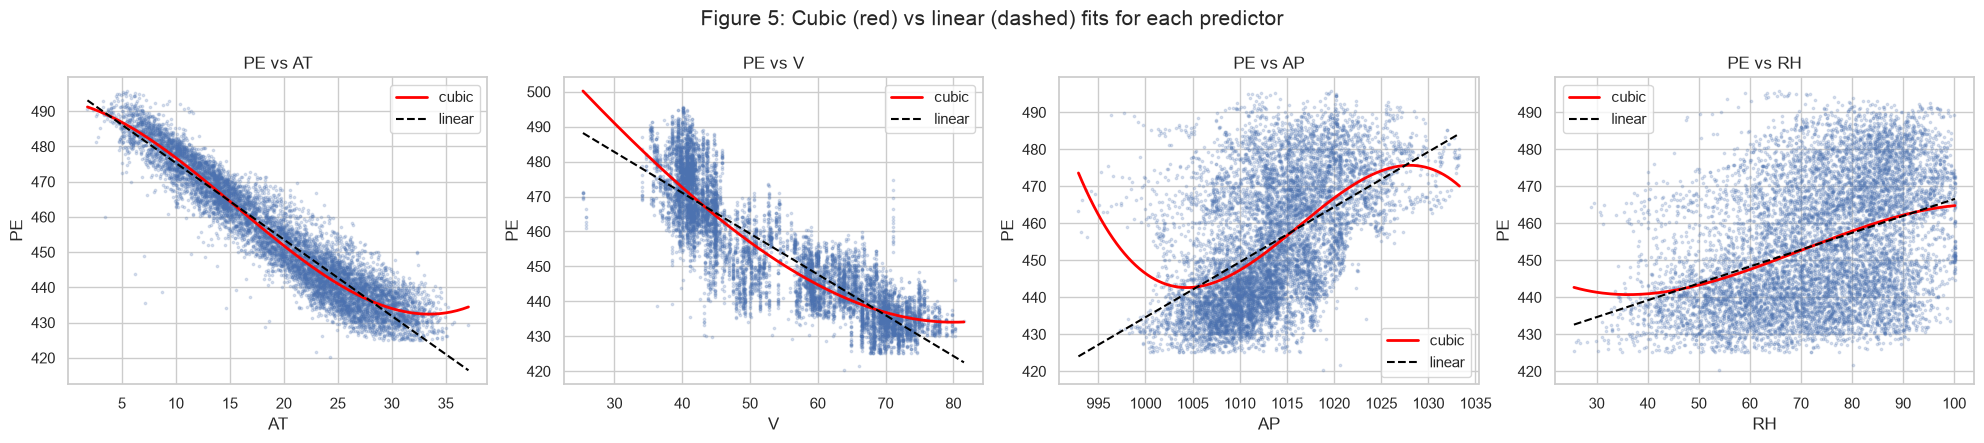

In [15]:
# cubic fit (red) against the straight line (dashed)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, feature in zip(axes, FEATURES):
    ax.scatter(df[feature], df[TARGET], s=3, alpha=0.2)
    x_line = np.linspace(df[feature].min(), df[feature].max(), 200)
    x_grid_powers = sm.add_constant(poly.fit_transform((x_line - df[feature].mean()).reshape(-1, 1)), has_constant="add")
    ax.plot(x_line, cubic_models[feature].predict(x_grid_powers), color="red", lw=2, label="cubic")

    model = simple_models[feature]
    ax.plot(x_line, model.params["Intercept"] + model.params[feature] * x_line, color="black", ls="--", lw=1.5, label="linear")
    ax.set(xlabel=feature, ylabel=TARGET, title=f"PE vs {feature}")
    ax.legend()
fig.suptitle("Figure 5: Cubic (red) vs linear (dashed) fits for each predictor", fontsize=15)
plt.tight_layout()
plt.show()

**Answer.** **Yes, there is statistically significant evidence of nonlinearity for every predictor.** The nested F-test of the cubic model against the linear model rejects $H_0:\beta_2=\beta_3=0$ for all four predictors (p = 3e-285 for AT, 7e-165 for V, 4e-84 for AP and 4e-5 for RH).

- **AT:** both the $X^2$ and $X^3$ terms are highly significant, and R^2 rises from 0.899 to 0.912. The cubic captures the gentle curvature seen in the residual plot in (c).
- **V:** $X^2$ is highly significant and $X^3$ is marginally significant (p = 0.014). R^2 rises from 0.757 to 0.775.
- **AP:** both terms are significant, and R^2 rises from 0.269 to 0.298.
- **RH:** only $X^3$ is significant (p = 1.4e-5) and $X^2$ is not (p = 0.10), with a negligible gain in R^2 (0.152 to 0.154).

Because n is so large, even tiny departures from linearity are statistically significant. In **practical** terms the nonlinearity is modest: the cubic curves in Figure 5 stay close to the straight lines over most of the data, and the largest gain in R^2 is about 0.03. The clearest practical nonlinearity is for AT, V and AP; for RH it is significant but negligible.

(Note: with raw values the cubic design for AP is numerically rank-deficient, which is why each predictor is centered first.)

### (g) Interactions of Predictors

In [16]:
# regression with all four predictors and all six pairwise interactions
interaction_model = smf.ols(f"{TARGET} ~ (" + " + ".join(FEATURES) + ")**2", data=df).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:08:58   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [17]:
# significance of the interaction terms only
interaction_terms = [term for term in interaction_model.params.index if ":" in term]
pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_terms],
    "p-value": interaction_model.pvalues[interaction_terms],
    f"Significant at alpha={ALPHA}": interaction_model.pvalues[interaction_terms] < ALPHA,
})

,Coefficient,p-value,Significant at alpha=0.05
AT:V,0.0210,3.3334e-117,True
AT:AP,0.0018,4.5205e-01,False
AT:RH,-0.0052,1.2169e-10,True
V:AP,0.0068,2.8770e-07,True
V:RH,0.0008,8.6194e-02,False
AP:RH,-0.0016,3.3606e-02,True


**Answer.** **Yes.** In the full model with all six pairwise interactions (R^2 = 0.936, up from 0.929 without interactions), four interactions are statistically significant at alpha = 0.05:

| Interaction | p-value | Significant? |
|---|---|---|
| AT:V | 3e-117 | yes (by far the strongest) |
| AT:RH | 1e-10 | yes |
| V:AP | 3e-7 | yes |
| AP:RH | 0.034 | yes (borderline) |
| V:RH | 0.086 | no |
| AT:AP | 0.45 | no |

The positive **AT:V** interaction means that the negative effect of temperature on output becomes weaker at higher exhaust vacuum (and vice versa). Once interactions are included, some main effects (for example, AT with p = 0.067) lose individual significance. That happens because main effects in an interaction model are conditional effects evaluated at zero for the other variables, and multicollinearity with the product terms inflates their standard errors. By the hierarchy principle they should stay in the model anyway.

### (h) Improvement

A single random 70/30 train/test split (fixed seed) is used here and reused for KNN in (i), so every model is scored on the same test points.

In [18]:
# 70/30 split, reused by the KNN models in (i)
train_df, test_df = train_test_split(df, train_size=0.7, random_state=SEED)
print(f"Train: {len(train_df)}  Test: {len(test_df)}")


def mse_report(model, name):
    # train and test MSE of one fitted model
    return {
        "Model": name,
        "# terms": len(model.params) - 1,
        "Train MSE": mean_squared_error(train_df[TARGET], model.predict(train_df)),
        "Test MSE": mean_squared_error(test_df[TARGET], model.predict(test_df)),
    }


# linear model with all predictors, trained on the 70%
linear_formula = f"{TARGET} ~ " + " + ".join(FEATURES)
linear_70 = smf.ols(linear_formula, data=train_df).fit()
print(linear_70.summary().tables[1])

Train: 6697  Test: 2871
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    467.8414     11.502     40.673      0.000     445.293     490.390
AT            -2.0044      0.018   -110.340      0.000      -2.040      -1.969
V             -0.2271      0.009    -26.301      0.000      -0.244      -0.210
AP             0.0493      0.011      4.416      0.000       0.027       0.071
RH            -0.1600      0.005    -32.337      0.000      -0.170      -0.150


**Model with all pairwise interactions and quadratic terms.** Backward elimination removes the term with the largest p-value, one at a time, while that p-value is above alpha = 0.05. To keep the model **hierarchical** (the "be careful about interaction terms" part), a main effect $X$ can only be removed once no remaining $X^2$ or $X{:}Z$ term contains it.

In [19]:
# four main effects, four squares and six pairwise interactions
main_terms = list(FEATURES)
quad_terms = [f"I({feature} ** 2)" for feature in FEATURES]
inter_terms_all = [f"{a}:{b}" for a, b in combinations(FEATURES, 2)]
all_terms = main_terms + quad_terms + inter_terms_all


def parents(term):
    # main effects that a square or an interaction term is built from
    if term.startswith("I("):
        return {term[2:term.index(" ")]}
    if ":" in term:
        return set(term.split(":"))
    return set()


def backward_eliminate(terms, data, alpha=ALPHA):
    # drop the least significant term one at a time, keeping the model hierarchical
    terms = list(terms)
    steps = []
    while True:
        model = smf.ols(f"{TARGET} ~ " + " + ".join(terms), data=data).fit()
        p_values = model.pvalues.drop("Intercept")

        # a main effect stays as long as a square or an interaction still uses it
        protected = set().union(*(parents(term) for term in terms))
        droppable = p_values[[term for term in p_values.index if term not in protected]]
        if droppable.empty or droppable.max() <= alpha:
            return model, terms, steps
        worst_term = droppable.idxmax()
        steps.append({"Removed": worst_term, "p-value": droppable.max()})
        terms.remove(worst_term)


# all terms, then the model left after elimination
full_quad_70 = smf.ols(f"{TARGET} ~ " + " + ".join(all_terms), data=train_df).fit()
reduced_70, kept_terms, elim_history = backward_eliminate(all_terms, train_df)

print("Elimination steps:")
display(pd.DataFrame(elim_history))
print("Final model:", " + ".join(kept_terms))
print(reduced_70.summary())

Elimination steps:


,Removed,p-value
0,V:RH,0.8674
1,I(V ** 2),0.6077
2,V:AP,0.3578


Final model: AT + V + AP + RH + I(AT ** 2) + I(AP ** 2) + I(RH ** 2) + AT:V + AT:AP + AT:RH + AP:RH
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:08:58   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [20]:
# train and test MSE of the three linear models
lin_results = pd.DataFrame([
    mse_report(linear_70, "Linear, all predictors"),
    mse_report(full_quad_70, "All interactions + quadratics (before elimination)"),
    mse_report(reduced_70, "Interactions + quadratics after p-value elimination"),
]).set_index("Model")
lin_results

,# terms,Train MSE,Test MSE
Model,,,
"Linear, all predictors",4,20.5808,21.2399
All interactions + quadratics (before elimination),14,17.8878,18.6473
Interactions + quadratics after p-value elimination,11,17.8908,18.6600


**Answer.** **Yes, the model improves.**

| Model | # terms | Train MSE | Test MSE |
|---|---|---|---|
| Linear, all 4 predictors | 4 | 20.58 | 21.24 |
| All interactions + quadratics (full, 14 terms) | 14 | 17.89 | **18.65** |
| After hierarchical p-value elimination | 11 | 17.89 | 18.66 |

Backward elimination on the 70% training set removed **V:RH** (p = 0.87), then **V^2** (p = 0.61), then **V:AP** (p = 0.36). The final model is

$$PE \sim AT + V + AP + RH + AT^2 + AP^2 + RH^2 + AT{:}V + AT{:}AP + AT{:}RH + AP{:}RH$$

Every remaining term has p < 0.002.

Adding interactions and quadratic terms lowers the **test MSE by about 12%** (21.24 to 18.66). The drop shows up on held-out data, so it is not just overfitting. The train and test MSEs of the reduced model are close (17.89 vs. 18.66), so it is not overfit. Removing the three insignificant terms costs essentially nothing (a test MSE of 18.66 vs. 18.65) and gives a simpler, more interpretable model. The full 14-term model is technically the linear-regression model with the smallest test MSE, but the difference is negligible.

Note that the selected terms on this 70% split differ somewhat from (g). For example, AT:AP is kept here while V:AP is dropped. Once quadratic terms enter the model, the interactions compete with them for the same curvature, so which interaction survives depends on which other terms are present.

### (i) KNN

KNN regression uses the same 70/30 split, with $k\in\{1,\dots,100\}$. *Normalized* means min-max scaling to $[0,1]$. The scaler is fit on the training set only and then applied to the test set. The best $k$ has the lowest test MSE; ties go to the larger $k$ (the simpler model).

In [21]:
# same 70/30 split as (h)
train_X_raw, test_X_raw = train_df[FEATURES].to_numpy(), test_df[FEATURES].to_numpy()
train_y, test_y = train_df[TARGET].to_numpy(), test_df[TARGET].to_numpy()

# min-max scaler fit on the training rows only, so the test set stays unseen
scaler = MinMaxScaler().fit(train_X_raw)
feature_sets = {
    "Raw": (train_X_raw, test_X_raw),
    "Normalized": (scaler.transform(train_X_raw), scaler.transform(test_X_raw)),
}

# train and test MSE for every k from 1 to 100
K_VALUES = np.arange(1, 101)
knn_curves = {}
for name, (train_X, test_X) in feature_sets.items():
    knn_rows = []
    for k in K_VALUES:
        model = KNeighborsRegressor(n_neighbors=k).fit(train_X, train_y)
        knn_rows.append({
            "k": k,
            "Train MSE": mean_squared_error(train_y, model.predict(train_X)),
            "Test MSE": mean_squared_error(test_y, model.predict(test_X)),
        })
    knn_curves[name] = pd.DataFrame(knn_rows).set_index("k")


def best_k(errors):
    # k with the lowest test MSE and tie goes to the smallest k
    lowest = errors["Test MSE"].min()
    return int(errors.index[np.isclose(errors["Test MSE"], lowest)].min())


# best k for raw and for normalized features
knn_best = pd.DataFrame([
    {"Features": name, "Best k": best_k(errors), "Train MSE": errors.loc[best_k(errors), "Train MSE"], "Test MSE": errors.loc[best_k(errors), "Test MSE"]}
    for name, errors in knn_curves.items()
]).set_index("Features")
knn_best

,Best k,Train MSE,Test MSE
Features,,,
Raw,5,10.6008,15.7268
Normalized,4,8.4543,14.2913


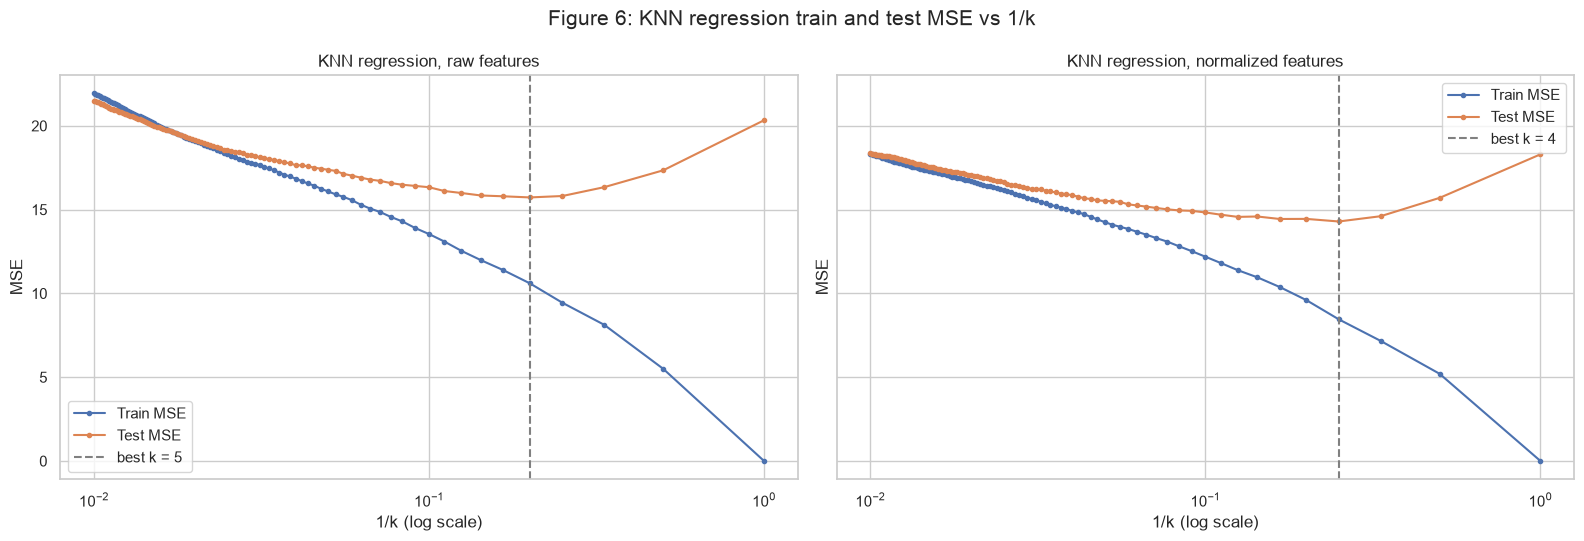

In [22]:
# train and test MSE against 1/k, so flexibility increases to the right
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, (name, errors) in zip(axes, knn_curves.items()):
    inv_k = 1 / errors.index.to_numpy()
    ax.plot(inv_k, errors["Train MSE"], marker="o", ms=3, label="Train MSE")
    ax.plot(inv_k, errors["Test MSE"], marker="o", ms=3, label="Test MSE")

    k_star = knn_best.loc[name, "Best k"]
    ax.axvline(1 / k_star, ls="--", color="gray", label=f"best k = {k_star}")
    ax.set_xscale("log")
    ax.set(xlabel="1/k (log scale)", ylabel="MSE", title=f"KNN regression, {name.lower()} features")
    ax.legend()
fig.suptitle("Figure 6: KNN regression train and test MSE vs 1/k", fontsize=15)
plt.tight_layout()
plt.show()

**Answer.**

| Features | Best k | Train MSE | Test MSE |
|---|---|---|---|
| Raw | **5** | 10.60 | 15.73 |
| Normalized (min-max) | **4** | 8.45 | **14.29** |

Figure 6 shows the classic bias-variance trade-off as a function of 1/k (model flexibility):
- **Train MSE** falls steadily as 1/k grows and reaches 0 at k = 1, where each training point is its own nearest neighbour.
- **Test MSE** is U-shaped. For large k (small 1/k) the model oversmooths (high bias, test MSE above 18 to 21). For k = 1 it overfits the noise (high variance, test MSE of about 18 to 20). The minimum is at a small k of 4 to 5.

**Normalization helps.** On the raw scale, V (range about 56) and RH (range about 75) dominate the Euclidean distance, while AT (range about 35), the most informative predictor, counts for comparatively less. Min-max scaling puts all four predictors on equal footing, which lowers the best test MSE from 15.73 to 14.29.

### (j ) Compare KNN and Linear

In [23]:
# linear and KNN models side by side, sorted by test MSE
best_lin_name = lin_results["Test MSE"].idxmin()
comparison = pd.concat([
    lin_results,
    pd.DataFrame([
        {"Model": f"KNN, {name.lower()} features (k={int(row['Best k'])})", "# terms": "-",
         "Train MSE": row["Train MSE"], "Test MSE": row["Test MSE"]}
        for name, row in knn_best.iterrows()
    ]).set_index("Model"),
]).sort_values("Test MSE")
print("Best linear regression model by test MSE:", best_lin_name)
comparison

Best linear regression model by test MSE: All interactions + quadratics (before elimination)


,# terms,Train MSE,Test MSE
Model,,,
"KNN, normalized features (k=4)",-,8.4543,14.2913
"KNN, raw features (k=5)",-,10.6008,15.7268
All interactions + quadratics (before elimination),14,17.8878,18.6473
Interactions + quadratics after p-value elimination,11,17.8908,18.6600
"Linear, all predictors",4,20.5808,21.2399


**Answer.** Test MSE on the same 30% hold-out set:

| Model | Test MSE |
|---|---|
| **KNN, normalized features (k = 4)** | **14.29** |
| KNN, raw features (k = 5) | 15.73 |
| Best linear regression (interactions + quadratics) | 18.65 |
| Linear, all predictors | 21.24 |

**KNN with normalized features beats the best linear regression model by about 23%** (14.29 vs. 18.65), and even KNN on raw features does better than it.

**Why:** n is large (6697 training points) and p is small (4). In that setting a flexible non-parametric method has enough data to estimate the regression function locally, so it can capture the nonlinearities and interactions we found in (f)-(g) without our having to specify them. Even with squares and pairwise products, the linear model is restricted to a particular parametric form. It still leaves out structure, such as the banded behaviour of V and higher-order interactions, which KNN picks up automatically.

**Trade-offs:** the gap between KNN's train and test MSE (8.5 vs. 14.3) is larger than the linear model's (17.9 vs. 18.7), so KNN has more variance. It also has no coefficients or p-values to interpret, it has to store and search the whole training set at prediction time, and it depends on feature scaling and would degrade quickly with more predictors (the curse of dimensionality). The linear model explains *how* each variable affects output, which is useful for engineering decisions. KNN gives the most accurate predictions.

## 2. ISLR: 2.4.1

For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

### (a) The sample size n is extremely large, and the number of predictors p is small.

**Answer. Better.** With a very large n and a small p, there is enough data to estimate a flexible model's many degrees of freedom reliably, so its variance stays low. At the same time, its low bias lets it fit the true f more closely than an inflexible model can.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

**Answer. Worse.** With p much larger than a small n, a flexible method has too many degrees of freedom relative to the data. It would **overfit**, fitting noise and producing high variance. An inflexible method (for example, a linear model with few parameters) is more stable and generalizes better.

### (c) The relationship between the predictors and response is highly non-linear.

**Answer. Better.** An inflexible method (for example, linear regression) cannot represent a highly nonlinear f and would have large **bias**. A flexible method has the degrees of freedom it needs to follow the nonlinear shape.

### (d) The variance of the error terms, i.e. $\sigma^2$ = Var($\epsilon$), is extremely high.

**Answer. Worse.** When the irreducible noise is very large, a flexible method will chase the noise and fit the random errors instead of the signal, which leads to high **variance** and overfitting. An inflexible method averages over the noise and is more robust.

## 3. ISLR: 2.4.7

In [24]:
# the six observations from the exercise
islr = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"],
}, index=pd.RangeIndex(1, 7, name="Obs."))
islr

,X1,X2,X3,Y
Obs.,,,,
1,0,3,0,Red
2,2,0,0,Red
3,0,1,3,Red
4,0,1,2,Green
5,-1,0,1,Green
6,1,1,1,Red


### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [25]:
# euclidean distance from each observation to the test point (0, 0, 0)
test_point = np.zeros(3)
islr["Distance"] = np.sqrt(((islr[["X1", "X2", "X3"]] - test_point) ** 2).sum(axis=1))
islr.sort_values("Distance")

,X1,X2,X3,Y,Distance
Obs.,,,,,
5,-1,0,1,Green,1.4142
6,1,1,1,Red,1.7321
2,2,0,0,Red,2.0000
4,0,1,2,Green,2.2361
1,0,3,0,Red,3.0000
3,0,1,3,Red,3.1623


**Answer.** Distance from the test point (0, 0, 0):

| Obs. | X1 | X2 | X3 | Y | Distance |
|---|---|---|---|---|---|
| 1 | 0 | 3 | 0 | Red | $\sqrt{9} = 3$ |
| 2 | 2 | 0 | 0 | Red | $\sqrt{4} = 2$ |
| 3 | 0 | 1 | 3 | Red | $\sqrt{10} \approx 3.162$ |
| 4 | 0 | 1 | 2 | Green | $\sqrt{5} \approx 2.236$ |
| 5 | -1 | 0 | 1 | Green | $\sqrt{2} \approx 1.414$ |
| 6 | 1 | 1 | 1 | Red | $\sqrt{3} \approx 1.732$ |

### (b) What is our prediction with K = 1? Why?

In [26]:
# closest observation
nearest = islr.sort_values("Distance")
print("K=1 neighbors:", nearest.head(1)["Y"].tolist(), "->", nearest.head(1)["Y"].mode()[0])

K=1 neighbors: ['Green'] -> Green


**Answer. Green.** With K = 1 the prediction is the class of the single nearest neighbour. That is observation 5 (distance $\sqrt2 \approx 1.414$), which is **Green**.

### (c) What is our prediction with K = 3? Why?

In [27]:
# majority vote among the three closest observations
print("K=3 neighbors:", nearest.head(3)["Y"].tolist(), "->", nearest.head(3)["Y"].value_counts().idxmax())

K=3 neighbors: ['Green', 'Red', 'Red'] -> Red


**Answer. Red.** The three nearest neighbors are observation 5 (Green, 1.414), observation 6 (Red, 1.732) and observation 2 (Red, 2.000). Red has the majority (2 of 3), so the estimated $P(\text{Red}\mid x_0) = 2/3$ and the prediction is **Red**.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

**Answer. Small.** A small K makes KNN very flexible, so its decision boundary can bend to follow a highly nonlinear Bayes boundary. A large K averages over many neighbors, which smooths the boundary toward something close to linear. That introduces high bias and misses the nonlinear structure.

### References

1. UCI Machine Learning Repository, *Combined Cycle Power Plant Data Set*: https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant
2. P. Tufekci, "Prediction of full load electrical power output of a base load operated combined cycle power plant using machine learning methods," *International Journal of Electrical Power & Energy Systems*, 60 (2014), 126-140. https://doi.org/10.1016/j.ijepes.2014.02.027
3. G. James, D. Witten, T. Hastie, R. Tibshirani, *An Introduction to Statistical Learning* (ISLR), Ch. 2 (bias-variance trade-off, KNN; exercises 2.4.1 and 2.4.7) and Ch. 3 (simple/multiple regression, outliers, high-leverage points, interactions, the hierarchical principle, polynomial regression, KNN vs. linear regression).
4. statsmodels, OLS regression and `OLSResults` (p-values, `compare_f_test`, influence measures): https://www.statsmodels.org/stable/regression.html
5. statsmodels, `OLSInfluence` (studentized residuals, leverage, Cook's distance): https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.OLSInfluence.html
6. scikit-learn, generating polynomial features (`PolynomialFeatures`): https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features
7. scikit-learn, `KNeighborsRegressor`: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
8. scikit-learn, `MinMaxScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
9. scikit-learn, `train_test_split`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
10. Wikipedia, *Cook's distance* (4/n rule of thumb): https://en.wikipedia.org/wiki/Cook%27s_distance